In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the dataset
file_path = 'Coulomb data - ML 5.8.2024.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path, sheet_name='Grouped_log')

# Define the target variable and the feature columns
target_column = 'COULOMB_LOG'  # Replace with your actual target column name

# Define features
features = ['AGE', 'PC1', 'PC2', 'PC1_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 
            'AEA', 'WR_HR', 'WR', 'ACC', 'VOID', 'FIBER', 'SLUMP', 'IS_PUMP', 'IS_LATEX', 
            'LATEX_AMOUNT', 'IS_LIGHT_WEIGHT', 'APPLICATION_ID', 'TOTAL_BINDER', 'TOTAL_AGG', 
            'w/b', 'b/a', 'SCM%', 'FAGG%', 'CAGG%', 'FA%', 'SS%', 'SF%']

# Create a directory for the plots if it doesn't exist
output_dir = 'plots'
os.makedirs(output_dir, exist_ok=True)

# Function to sanitize feature names for saving
def sanitize_filename(filename):
    return filename.replace("/", "_").replace("\\", "_")

# Plot scatter plots for each feature against the target
for feature in features:
    # plt.figure(figsize=(8, 6))
    plt.scatter(df[feature], df[target_column], alpha=0.5)
    # plt.title(f'Scatter plot of {feature} vs {target_column}')
    plt.xlabel(feature)
    plt.ylabel('Chloride permeability (Coulomb)')
    # plt.grid(True)

    # Sanitize feature name for saving
    sanitized_feature = sanitize_filename(feature)
    
    # Save the plot for each feature
    plt.savefig(os.path.join(output_dir, f'{sanitized_feature}_vs_Coulomb.png'), dpi=300, bbox_inches='tight')
    plt.close()  # Close the plot to save memory


In [8]:
# Calculate the correlation matrix
correlation_matrix = df[features + [target_column]].corr()

# Extract correlation of each feature with the target variable
correlation_with_target = correlation_matrix[target_column].drop(target_column)

# Display the correlation coefficients
print(correlation_with_target)

AGE                0.165325
PC1                0.288828
PC2               -0.044679
PC1_TYPE          -0.213568
FA                -0.152359
SS                -0.139636
SF                -0.027994
FAGG               0.071599
CAGG              -0.147137
WATER              0.282340
AEA                0.083126
WR_HR              0.085384
WR                 0.113528
ACC                0.176181
VOID              -0.024692
FIBER             -0.003820
SLUMP             -0.154604
IS_PUMP            0.036286
IS_LATEX          -0.078484
LATEX_AMOUNT      -0.235536
IS_LIGHT_WEIGHT    0.115195
APPLICATION_ID     0.163227
TOTAL_BINDER       0.124384
TOTAL_AGG         -0.116713
w/b                0.151165
b/a                0.162646
SCM%              -0.287413
FAGG%              0.116765
CAGG%             -0.116765
FA%               -0.165999
SS%               -0.156957
SF%               -0.024945
Name: COULOMB_LOG, dtype: float64


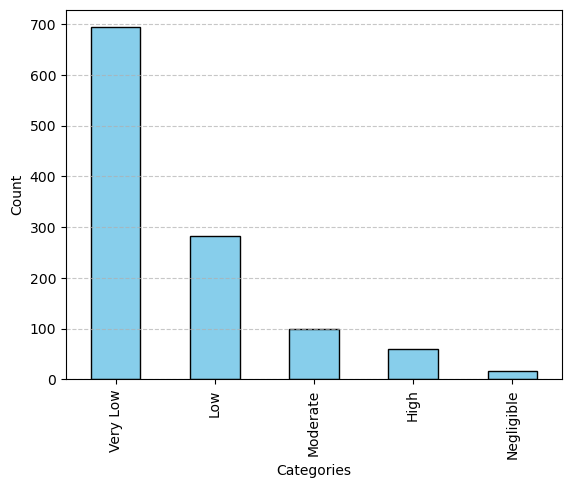

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'Grouped_MIX_NUM_with_Chloride_Penetrability.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path,sheet_name='Sheet1')

# Specify the column you want to plot
column_name = 'Chloride Ion Penetrability'  # Replace with your actual column name

# Calculate the value counts or the mean of the column for plotting (choose based on your data)
# If you want to plot counts of each unique value in the column
value_counts = df[column_name].value_counts()

# Create a bar plot
# plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
# plt.title(f'Bar Plot of {column_name}')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


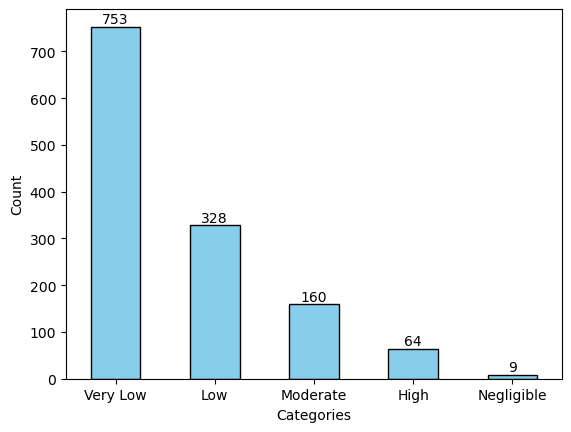

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'chloride_Classification.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Specify the column you want to plot
column_name = 'Chloride Ion Penetrability Class'  # Replace with your actual column name

# Calculate the value counts of the column for plotting
value_counts = df[column_name].value_counts()

# Create a bar plot
# plt.figure(figsize=(10, 6))
bars = value_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Add count numbers on top of each bar
for index, value in enumerate(value_counts):
    plt.text(index, value + 7, str(value), ha='center', fontsize=10)

# Set titles and labels
# plt.title(f'Bar Plot of {column_name}')
plt.xlabel('Categories')
plt.ylabel('Count')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.savefig('count_bar.png', dpi=300, bbox_inches='tight')

# Show the plot
# plt.show()


In [17]:
import pandas as pd

# Load the dataset
file_path = 'Coulomb data - ML 5.8.2024.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path, sheet_name='Grouped')

# Define a function to classify based on Coulomb value
def classify_coulomb(value):
    if value > 4000:
        return 'High'
    elif 2000 < value <= 4000:
        return 'Moderate'
    elif 1000 < value <= 2000:
        return 'Low'
    elif 100 < value <= 1000:
        return 'Very Low'
    else:
        return 'Negligible'

# Apply the classification function to add a new column
df['Chloride Ion Penetrability Class'] = df['COULOMB_TEST'].apply(classify_coulomb)  # Replace 'COULOMB_COLUMN_NAME' with your actual Coulomb column name

# Display the updated DataFrame
print(df.head())

# Save the updated DataFrame to a new Excel file if needed
df.to_excel('chloride_Classification.xlsx', index=False)


   COULOMB_TEST  AGE  PC1  PC2  PC1_TYPE   FA   SS  SF  FAGG  CAGG  ...  \
0    794.965517   28  560    0         1  100    0  45  1031  1930  ...   
1   3270.250000   28  658    0         9    0    0   0  1470  1330  ...   
2    913.400000   28  705    0         1  150    0   0   865  1800  ...   
3   1372.733333   28  420    0         1    0  240   0  1050  2050  ...   
4   3176.761905   28  470    0         1  190    0   0  1000  2050  ...   

   TOTAL_AGG       w/b       b/a      SCM%     FAGG%     CAGG%       FA%  \
0       2961  0.384397  0.238095  0.141844  0.348193  0.651807  0.141844   
1       2800  0.218845  0.235000  0.000000  0.525000  0.475000  0.000000   
2       2665  0.345029  0.320826  0.175439  0.324578  0.675422  0.175439   
3       3100  0.356061  0.212903  0.363636  0.338710  0.661290  0.000000   
4       3050  0.356061  0.216393  0.287879  0.327869  0.672131  0.287879   

        SS%      SF%  Chloride Ion Penetrability Class  
0  0.000000  0.06383               

In [34]:
from sklearn.ensemble import IsolationForest
import pandas as pd

file_path = 'chloride_Classification.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Define the features for Isolation Forest (excluding the target column)
features = df.drop(columns=['COULOMB_TEST','Chloride Ion Penetrability Class'])  # Replace 'target' with the name of your target column

# Train Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
df['anomaly_score'] = iso_forest.fit_predict(features)

# Identify and filter out anomalies
# cleaned_data = df[df['anomaly_score'] == 1]  # Keep only non-anomalous data points
output_file = "cleaned_dataset_with_iso_forest.xlsx"  # You can rename 'cleaned_dataset.xlsx' as needed
df.to_excel(output_file, index=False, sheet_name='Ori Cleaned Data')


# # Save the cleaned data to a new CSV file
# df.to_csv("cleaned_dataset_with_iso_forest.csv", index=False)  # You can rename 'cleaned_dataset.csv' as needed

print("Cleaned data saved successfully to 'cleaned_dataset.csv'.")



Cleaned data saved successfully to 'cleaned_dataset.csv'.


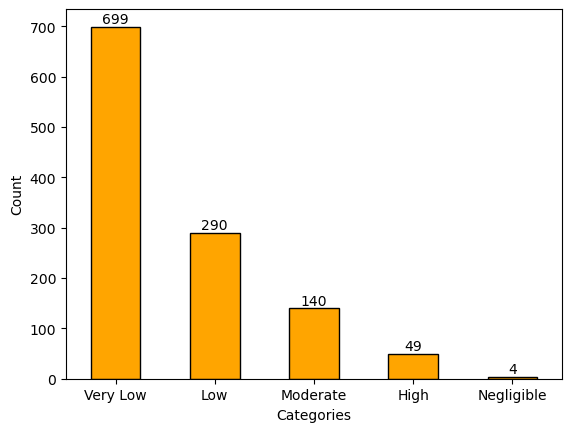

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'cleaned_dataset_with_iso_forest.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Specify the column you want to plot
column_name = 'Chloride Ion Penetrability Class'  # Replace with your actual column name

# Calculate the value counts of the column for plotting
value_counts = df[column_name].value_counts()

# Create a bar plot
# plt.figure(figsize=(10, 6))
bars = value_counts.plot(kind='bar', color='orange', edgecolor='black')

# Add count numbers on top of each bar
for index, value in enumerate(value_counts):
    plt.text(index, value + 7, str(value), ha='center', fontsize=10)

# Set titles and labels
# plt.title(f'Bar Plot of {column_name}')
plt.xlabel('Categories')
plt.ylabel('Count')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.savefig('count_bar_after_anomaly.png', dpi=300, bbox_inches='tight')

# Show the plot
# plt.show()


/Users/zhangtianjie/opt/anaconda3/envs/ag/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 15.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/zhangtianjie/opt/anaconda3/envs/ag/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 21.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


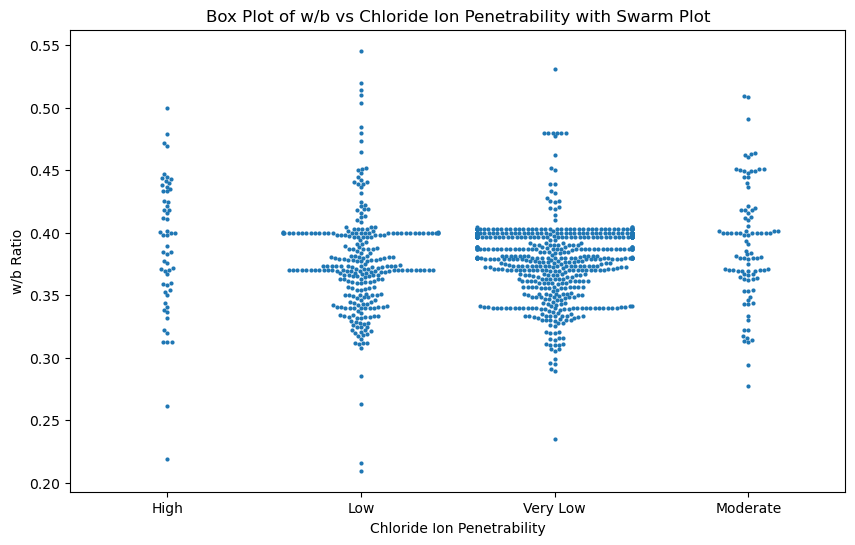

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'full_results_with_predictions.csv'
df = pd.read_csv(file_path)
# Create a box plot for 'w/b' vs 'Chloride Ion Penetrability' with points using swarmplot
plt.figure(figsize=(10, 6))

# Create a boxplot
# sns.boxplot(x='Chloride Ion Penetrability', y='w/b', data=df)

# Add a swarmplot to show individual points
sns.swarmplot(x='Chloride Ion Penetrability', y='w/b', data=df, size=3)

plt.title('Box Plot of w/b vs Chloride Ion Penetrability with Swarm Plot')
plt.xlabel('Chloride Ion Penetrability')
plt.ylabel('w/b Ratio')
plt.show()


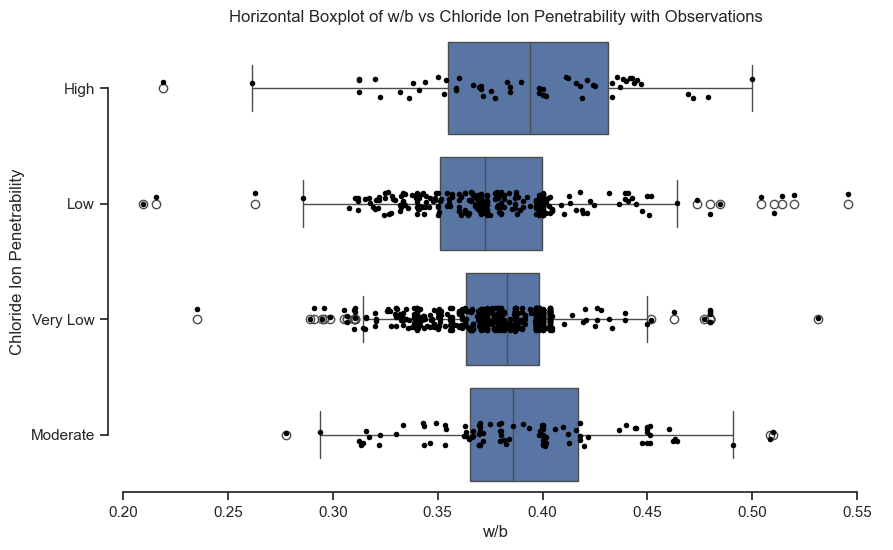

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (assuming the dataset is already loaded as 'df')
sns.set_theme(style="ticks")

# Initialize the figure
plt.figure(figsize=(10, 6))

# Create a horizontal boxplot
ax = sns.boxplot(x='w/b', y='Chloride Ion Penetrability', data=df)

# Add stripplot to display individual data points
sns.stripplot(x='w/b', y='Chloride Ion Penetrability', data=df, color='black', size=4)

# Adjust the plot's aesthetics
sns.despine(trim=True)
plt.title('Horizontal Boxplot of w/b vs Chloride Ion Penetrability with Observations')

plt.show()


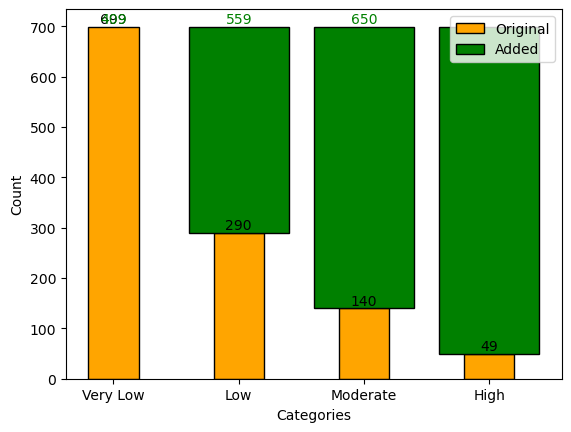

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'cleaned_dataset_with_iso_forest.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Specify the column you want to plot
column_name = 'Chloride Ion Penetrability Class'  # Replace with your actual column name

# Calculate the value counts of the column for plotting
value_counts = df[column_name].value_counts()

# Remove the 'Negligible' category
value_counts = value_counts[value_counts.index != 'Negligible']

# Data to add (409 for Low, 559 for Moderate, 650 for High)
added_values = pd.Series([409, 559, 650], index=['Low', 'Moderate', 'High'])

# Reset to default Matplotlib style (optional)
plt.style.use('default')  # You can use other styles like 'ggplot', 'seaborn-darkgrid', etc.

# Create the plot for the original data
# plt.figure(figsize=(10, 6))
bars = plt.bar(value_counts.index, value_counts.values, color='orange', edgecolor='black', label='Original',width=0.4)

# Create the plot for the added data (stacked)
added_bars = plt.bar(added_values.index, added_values.values, bottom=value_counts[added_values.index], 
                     color='green', edgecolor='black', label='Added')

# Add count numbers on top of the original bars
for index, value in enumerate(value_counts):
    plt.text(index, value + 7, str(value), ha='center', fontsize=10)

# Add count numbers on top of the added bars
for index, value in enumerate(added_values):
    original_value = value_counts[added_values.index[index]]
    plt.text(index, original_value + value + 7, str(value), ha='center', fontsize=10, color='green')

# Set titles and labels
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Add a legend
plt.legend()

# Save the plot
plt.savefig('count_bar_with_added_samples.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


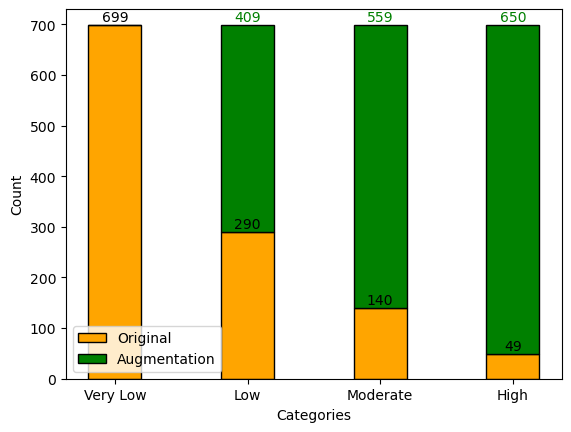

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'cleaned_dataset_with_iso_forest.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Specify the column you want to plot
column_name = 'Chloride Ion Penetrability Class'  # Replace with your actual column name

# Calculate the value counts of the column for plotting
value_counts = df[column_name].value_counts()

# Remove the 'Negligible' category
value_counts = value_counts[value_counts.index != 'Negligible']

# Data to add (409 for Low, 559 for Moderate, 650 for High)
added_values = pd.Series([0,409, 559, 650], index=['Very Low','Low', 'Moderate', 'High'])

# Reset to default Matplotlib style (optional)
plt.style.use('default')  # You can use other styles like 'ggplot', 'seaborn-darkgrid', etc.

# Create the plot for the original data
# plt.figure(figsize=(10, 6))
bars = plt.bar(value_counts.index, value_counts.values, color='orange', edgecolor='black', label='Original',width=0.4)

# Create the plot for the added data (stacked)
added_bars = plt.bar(added_values.index, added_values.values, bottom=value_counts[added_values.index], 
                     color='green', edgecolor='black', label='Augmentation',width=0.4)

# Add count numbers on top of the original bars
for index, value in enumerate(value_counts):
    plt.text(index, value + 7, str(value), ha='center', fontsize=10)

# Add count numbers on top of the added bars (excluding "Very Low")
for index, value in enumerate(added_values):
    if added_values.index[index] != 'Very Low':  # Skip "Very Low" category
        original_value = value_counts[added_values.index[index]]
        plt.text(index, original_value + value + 7, str(value), ha='center', fontsize=10, color='green')

# Set titles and labels
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.ylim(0,730)

# Add a legend
plt.legend()

# Save the plot
plt.savefig('count_bar_with_added_samples.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()
